In [1]:
import os
import json
import shutil
import pandas as pd
import cv2
import numpy as np
from tqdm import tqdm  # Progress bar
import matplotlib.pyplot as plt
from tqdm import tqdm

import numpy as np
import time
import torch
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib 

In [2]:
# Load metadata
json_path = "D:\\sem3\\Image-Data\\photos.json"
photos_data = []
with open(json_path, "r", encoding="utf-8") as f:
    for line in f:
        photos_data.append(json.loads(line))

photos_df = pd.DataFrame(photos_data)

photos_df.head()

,photo_id,business_id,caption,label
0,zsvj7vloL4L5jhYyPIuVwg,Nk-SJhPlDBkAZvfsADtccA,Nice rock artwork everywhere and craploads of ...,inside
1,HCUdRJHHm_e0OCTlZetGLg,yVZtL5MmrpiivyCIrVkGgA,,outside
2,vkr8T0scuJmGVvN2HJelEA,_ab50qdWOk0DdB6XOrBitw,oyster shooter,drink
3,pve7D6NUrafHW3EAORubyw,SZU9c8V2GuREDN5KgyHFJw,Shrimp scampi,food
4,H52Er-uBg6rNrHcReWTD2w,Gzur0f0XMkrVxIwYJvOt2g,,food


In [3]:
subset_df = photos_df.sample(n=20000, random_state=42)  # Ensure reproducibility
subset_df.to_csv("subset")
# Show first few rows
subset_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 32568 to 129705
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   photo_id     20000 non-null  object
 1   business_id  20000 non-null  object
 2   caption      20000 non-null  object
 3   label        20000 non-null  object
dtypes: object(4)
memory usage: 781.2+ KB


In [4]:
import os
import shutil

# Define source and destination folders
photos_folder = "D:\\sem3\\Image-Data\\photos\\"  # Folder with all photos
subset_folder = "D:\\sem3\\Image-Data\\subset-photos\\"  # Folder for subset images

# Create the new folder if it doesn't exist
os.makedirs(subset_folder, exist_ok=True)

# Get a list of already moved images
existing_images = set(os.listdir(subset_folder))  # Set of already moved files

# Count how many images need to be moved
remaining_images = [photo_id for photo_id in subset_df["photo_id"] if f"{photo_id}.jpg" not in existing_images]

if not remaining_images:
    print(f"All subset images are already moved to {subset_folder}")
else:
    print(f"⚠ Moving {len(remaining_images)} images to {subset_folder}...")

    moved_count = 0
    for photo_id in remaining_images:
        src_path = os.path.join(photos_folder, f"{photo_id}.jpg")
        dest_path = os.path.join(subset_folder, f"{photo_id}.jpg")
        
        if os.path.exists(src_path):
            shutil.move(src_path, dest_path)
            moved_count += 1

    print(f"Moved {moved_count} new images to {subset_folder}")

All subset images are already moved to D:\sem3\Image-Data\subset-photos\


In [5]:
def apply_intensity_threshold(image, threshold=128):
    """Apply binary intensity thresholding."""
    _, thresholded = cv2.threshold(image, threshold, 255, cv2.THRESH_BINARY)
    return thresholded

def apply_histogram_equalization(image):
    """Apply histogram equalization for contrast enhancement."""
    return cv2.equalizeHist(image)

def apply_gaussian_blur(image, kernel_size=(5,5)):
    """Apply Gaussian blur to reduce noise."""
    return cv2.GaussianBlur(image, kernel_size, 0)

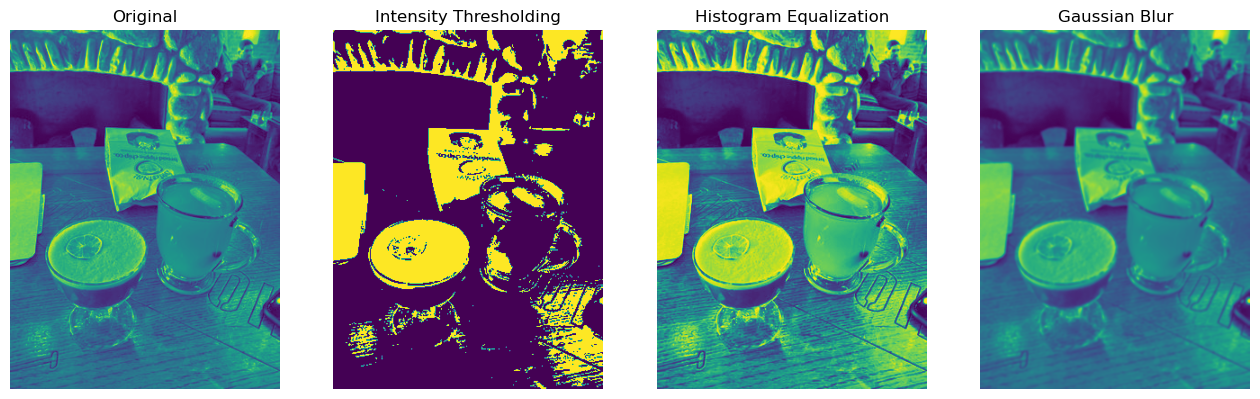

In [6]:
# Select a random image to test preprocessing
sample_image_id = subset_df.iloc[5]["photo_id"]
image_path = os.path.join(subset_folder, f"{sample_image_id}.jpg")

# Load image in grayscale
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Apply preprocessing
thresholded = apply_intensity_threshold(image)
equalized = apply_histogram_equalization(image)
blurred = apply_gaussian_blur(image)

# Show original and processed images
fig, axs = plt.subplots(1, 4, figsize=(16, 5))
axs[0].imshow(image)
axs[0].set_title("Original")

axs[1].imshow(thresholded)
axs[1].set_title("Intensity Thresholding")

axs[2].imshow(equalized)
axs[2].set_title("Histogram Equalization")

axs[3].imshow(blurred)
axs[3].set_title("Gaussian Blur")

for ax in axs:
    ax.axis("off")

plt.show()

In [7]:
processed_folder = "D:\\sem3\\Image-Data\\processed-photos"
os.makedirs(processed_folder, exist_ok=True)

# Check if preprocessing is already done
processed_images = set(os.listdir(processed_folder))  # Get list of already processed files

if len(processed_images) >= len(subset_df):  # Check if all images are already processed
    print(f" Preprocessing already completed! ({len(processed_images)} images available)")
else:
    print(f"Processing {len(subset_df) - len(processed_images)} new images...")

    # Process and save only unprocessed images
    for photo_id in tqdm(subset_df["photo_id"], desc="Processing Images"):
        input_path = os.path.join("D:\\sem3\\Image-Data\\subset-photos\\", f"{photo_id}.jpg")
        output_path = os.path.join(processed_folder, f"{photo_id}.jpg")

        if os.path.exists(input_path) and f"{photo_id}.jpg" not in processed_images:
            img = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)  # Load in grayscale
            
            if img is None:  # Skip if image loading failed
                print(f"Skipping unreadable image: {input_path}")
                continue

            img = apply_intensity_threshold(img)  # Apply thresholding
            img = apply_histogram_equalization(img)  # Apply histogram equalization
            img = apply_gaussian_blur(img)  # Apply Gaussian blur

            cv2.imwrite(output_path, img)  # Save processed image

    print(f"Preprocessing completed! Processed images saved in: {processed_folder}")

Processing 6 new images...


Processing Images:  11%|██████                                                  | 2180/20000 [00:01<00:10, 1702.13it/s]

Skipping unreadable image: D:\sem3\Image-Data\subset-photos\1MOGQBWogR8oJr1WgERi9g.jpg


Processing Images:  38%|█████████████████████                                   | 7521/20000 [00:04<00:06, 1791.88it/s]

Skipping unreadable image: D:\sem3\Image-Data\subset-photos\pW1IPuTdLIUB61goirbXaA.jpg


...

Skipping unreadable image: D:\sem3\Image-Data\subset-photos\W94rrCn0O5K1lkfD26m4tw.jpg


Processing Images:  94%|███████████████████████████████████████████████████▉   | 18892/20000 [00:09<00:00, 1738.56it/s]

Skipping unreadable image: D:\sem3\Image-Data\subset-photos\7xcWPjcE4mxoQ1AjvvKJZg.jpg
Skipping unreadable image: D:\sem3\Image-Data\subset-photos\JZZ716oX6_MqH6L_MkWK-A.jpg


Processing Images: 100%|███████████████████████████████████████████████████████| 20000/20000 [00:10<00:00, 1953.48it/s]

Preprocessing completed! Processed images saved in: D:\sem3\Image-Data\processed-photos


In [8]:
import concurrent.futures
import os
import cv2

# Function to load and process a single image
def process_image(row):
    img_path = os.path.join(processed_folder, f"{row.photo_id}.jpg")  # Use dot notation
    
    if not os.path.exists(img_path):
        return None  # Skip missing files
    
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Load preprocessed image
    if img is None:
        return None  # Skip unreadable images
    
    img = cv2.resize(img, (64, 64))  # Resize for uniformity
    return img.flatten(), row.label  # Use dot notation for label

# Use multi-threading to load images faster
X = []
y = []
with concurrent.futures.ThreadPoolExecutor() as executor:
    results = list(executor.map(process_image, subset_df.itertuples(index=False)))

# Filter out None values (failed loads)
filtered_results = [r for r in results if r is not None]
if filtered_results:  # Ensure there's data
    X, y = zip(*filtered_results)
    X = np.array(X)
    y = np.array(y)
else:
    X, y = np.array([]), np.array([])  # Handle empty case

print(f"Feature Matrix Shape: {X.shape}, Labels Shape: {y.shape}")

Feature Matrix Shape: (19994, 4096), Labels Shape: (19994,)


In [9]:
X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training Set: {X_train_k.shape}, Testing Set: {X_test_k.shape}")

Training Set: (15995, 4096), Testing Set: (3999, 4096)


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

# Load pre-trained VGG16 model
vgg_model = models.vgg16(pretrained=True)

# Modify the final classifier layer
vgg_model.classifier[6] = nn.Sequential(
    nn.Linear(in_features=4096, out_features=512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(in_features=512, out_features=256),
    nn.ReLU(),
    nn.Linear(in_features=256, out_features=5),
    nn.Softmax()
)

# Move the model to the GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vgg_model.to(device)

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from torch.utils.data import DataLoader, TensorDataset
import torch
import torch.nn.functional as F

# Convert labels to numeric values (ensure labels are float for BCEWithLogitsLoss)
label_encoder = LabelEncoder()
y_train_k = label_encoder.fit_transform(y_train_k).astype(float)
y_test_k = label_encoder.transform(y_test_k).astype(float)

# Standardize the feature matrix (X)
scaler = StandardScaler()
X_train_k = scaler.fit_transform(X_train_k)
X_test_k = scaler.transform(X_test_k)

# Convert to torch tensors
X_train_tensor = torch.tensor(X_train_k, dtype=torch.float32).view(-1, 1, 64, 64)  # Keep 1 channel for now
X_test_tensor = torch.tensor(X_test_k, dtype=torch.float32).view(-1, 1, 64, 64)

# Resize to 224x224 for VGG compatibility
X_train_tensor = F.interpolate(X_train_tensor, size=(224, 224), mode='bilinear', align_corners=False)
X_test_tensor = F.interpolate(X_test_tensor, size=(224, 224), mode='bilinear', align_corners=False)

# Convert grayscale images to 3 channels
X_train_tensor = X_train_tensor.repeat(1, 3, 1, 1)  # Shape: [batch_size, 3, 224, 224]
X_test_tensor = X_test_tensor.repeat(1, 3, 1, 1)  # Shape: [batch_size, 3, 224, 224]

# Convert labels to tensor (float for BCEWithLogitsLoss)
y_train_tensor = torch.tensor(y_train_k, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_k, dtype=torch.float32)

# Create DataLoader with optimizations
batch_size = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

# Verify the output shapes
print(f"Feature Tensor Shape (train): {X_train_tensor.shape}")
print(f"Feature Tensor Shape (test): {X_test_tensor.shape}")
print(f"Label Tensor Shape (train): {y_train_tensor.shape}")
print(f"Label Tensor Shape (test): {y_test_tensor.shape}")

In [ ]:
import torch.optim as optim

# Define loss function and optimizer
criterion = nn.BCEWithLogitsLoss()  # Suitable for binary classification tasks
optimizer = optim.Adam(vgg_model.parameters(), lr=0.0001)  # Adam optimizer

In [ ]:
import torch.optim as optim
import torch.cuda.amp as amp  # Mixed precision training

# Enable cuDNN optimizations for better speed if input sizes are consistent
torch.backends.cudnn.benchmark = True  

# Define loss function and optimizer
criterion = nn.BCEWithLogitsLoss().to(device)  # Move loss function to device
optimizer = optim.Adam(vgg_model.parameters(), lr=0.0001)  # Adam optimizer

# Mixed precision scaler for faster training
scaler = amp.GradScaler()

num_epochs = 10  # Set number of epochs
for epoch in range(num_epochs):
    vgg_model.train()  # Set model to training mode
    running_loss = 0.0
    correct_preds = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass with mixed precision
        with amp.autocast():
            outputs = vgg_model(inputs)
            loss = criterion(outputs.squeeze(), labels.float())

        # Backward pass and optimize
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Track loss and accuracy (avoid extra .item() calls)
        running_loss += loss.detach() * inputs.size(0)
        correct_preds += torch.sum((outputs.squeeze() > 0.5) == labels).item()

    # Compute average loss and accuracy
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_accuracy = correct_preds / len(train_loader.dataset)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.4f}")

In [ ]:
vgg_model.eval()  # Set the model to evaluation mode
test_loss = 0.0
correct_preds = 0
y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Forward pass
        outputs = vgg_model(inputs)
        loss = criterion(outputs.squeeze(), labels.float())

        # Track loss and accuracy
        test_loss += loss.item() * inputs.size(0)
        correct_preds += torch.sum((outputs.squeeze() > 0.5) == labels).item()

        # Collect true labels and predicted probabilities
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(outputs.squeeze().cpu().numpy())

test_loss /= len(test_loader.dataset)
test_accuracy = correct_preds / len(test_loader.dataset)

print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

In [ ]:
import torch

# Define the file path where you want to save the model
model_path = "vgg_model.pth"

# Save the model's state dictionary
torch.save(vgg_model.state_dict(), model_path)

print("Model saved successfully!")

In [ ]:
torch.save(vgg_model, "vgg_model_full.pth")

In [ ]:
print("Unique labels in dataset:", torch.unique(y_train_tensor))

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure y_true is a NumPy array
if isinstance(y_true, list):
    y_true = np.array(y_true)
elif isinstance(y_true, torch.Tensor):
    y_true = y_true.cpu().numpy()

# Ensure y_pred is a PyTorch tensor
if isinstance(y_pred, list):
    y_pred = [torch.tensor(p, dtype=torch.float32) if isinstance(p, (np.ndarray, np.float32, float)) else p for p in y_pred]
    y_pred = torch.stack(y_pred)

# Ensure y_pred has correct shape
if y_pred.dim() == 1:  # If shape is (batch_size,)
    y_pred = y_pred.unsqueeze(1)  # Expand to (batch_size, 1)

# Convert logits to probabilities
y_pred_proba = F.softmax(y_pred, dim=-1).detach().cpu().numpy()  # Use dim=-1 to handle different input shapes

# Ensure labels are within range of possible classes
num_classes = 5  # Adjust based on your dataset
y_pred_class = torch.argmax(y_pred, dim=-1).detach().cpu().numpy()

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred_class)

print(cm)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.title("Confusion Matrix")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Compute AUC score (if applicable)
try:
    auc = roc_auc_score(y_true, y_pred_proba, multi_class="ovr")  # One-vs-Rest AUC
    print(f"AUC: {auc:.4f}")
except ValueError as e:
    print(f"Error computing AUC: {e}")  # Handle cases where AUC computation fails